<a href="https://colab.research.google.com/github/lynnkaram/data-mining-and-modeling/blob/main/homework-2-single-cell-analysis/single_cell_rna_seq_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Biomedical Data Science 2026: Homework Assignment 2
### CBB & CPSC & S&DS (programming) Assignment

- Release Date: Week of Feb 23rd, 2026
- Due:  March 29th, 11:59pm

#### Name:  Lynn Karam

## Instructions
* You only need to write code with the `TODO` comments.
* You may write code outside of these blocks, but it will not be graded.
* If you make use of any online resource please cite the source in the code comments.
* You may use some small utility functions directly, but notice that directly copying large chunks of codes (even with variable name replacement) are not allowed and will be considered as plagrism.
* After writing your code, you can run the cell by either pressing "SHIFT"+"ENTER" or by clicking on "Run Cell" (denoted by a play symbol) in the upper bar of the notebook.
* After you are finished, turn in both the **.ipynb** version and the **PDF** version to Canvas.

## Part 1: Genome-Wide Association Study (GWAS) Visualization

### Introduction
In Genome-Wide Association Studies (GWAS), we test millions of Single Nucleotide Polymorphisms (SNPs) across the genome for association with a trait (like height or disease risk). The results of these tests are compiled into "Summary Statistics."

Because we perform millions of independent statistical tests, using a standard -value threshold of  would result in thousands of false positives. To account for this, we use a much stricter genome-wide significance threshold, typically the Bonferroni corrected threshold. In this assignment, you will analyze a thinned subset of the GIANT Consortium's GWAS on human height. You will calculate the appropriate significance thresholds and generate the two most common GWAS visualizations.

## 1.1 Data Loading and Preprocessing (5 pts)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# 1. Load the dataset (assuming columns: CHR, POS, SNP, P)
# TODO: Read 'height_gwas_sample.txt' into a pandas DataFrame.
# Note: it is tab-separated.
gwas_df = pd.read_csv("height_gwas_sample.txt", sep='\t');

# 2. Drop any rows with missing P-values
# TODO
gwas_df = gwas_df.dropna(subset=['p']);

# 3. Calculate the -log10(P-value) for visualization
# TODO: Add a new column '-log10(p)' to the dataframe
gwas_df['-log10(p)'] = -np.log10(gwas_df['p']);

print(f"Loaded {len(gwas_df)} SNPs for analysis.")

Loaded 255477 SNPs for analysis.


## 1.2 Multiple Testing Correction (5 pts)

In [ ]:
# To avoid false positives, calculate the Bonferroni significance threshold.

alpha = 0.05

# TODO: Calculate the Bonferroni threshold
bonferroni_threshold = alpha / len(gwas_df)

# TODO: Calculate the -log10 of the Bonferroni threshold (we need this to draw a line on our plot)
log_threshold = -np.log10(bonferroni_threshold)

# TODO: Count how many SNPs are strictly genome-wide significant
num_significant = (gwas_df['p'] < bonferroni_threshold).sum()

print(f"Bonferroni Threshold: {bonferroni_threshold:.2e}")
print(f"Number of significant SNPs: {num_significant}")

Bonferroni Threshold: 1.96e-07
Number of significant SNPs: 3103


## 1.3 Visualizing the Manhattan Plot (10 pts)

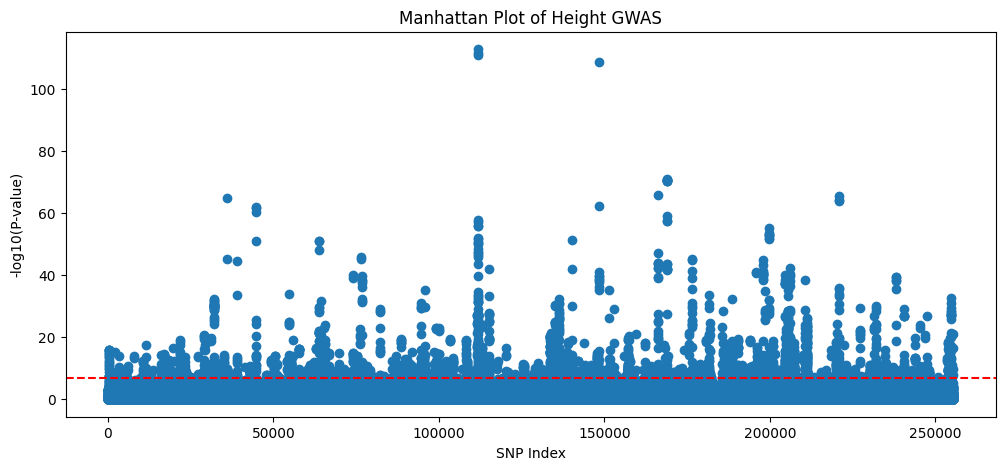

In [ ]:
# A Manhattan plot shows the -log10(P) of each SNP ordered by its position.
# For simplicity in this homework, we can plot the points
# sequentially based on their index.

plt.figure(figsize=(12, 5))

# TODO: Create a scatter plot of the -log10(P) values.
plt.scatter(gwas_df.index, gwas_df['-log10(p)'])

# TODO: Add a horizontal line (axhline) representing the log_threshold calculated in 1.2.
# Make it red and dashed.
plt.axhline(y=log_threshold, color = 'red', linestyle = '--', label = "Bonferroni threshold")

plt.title("Manhattan Plot of Height GWAS")
plt.xlabel("SNP Index")
plt.ylabel("-log10(P-value)")
plt.show()

## 1.4 Visualizing the QQ Plot (10 pts)

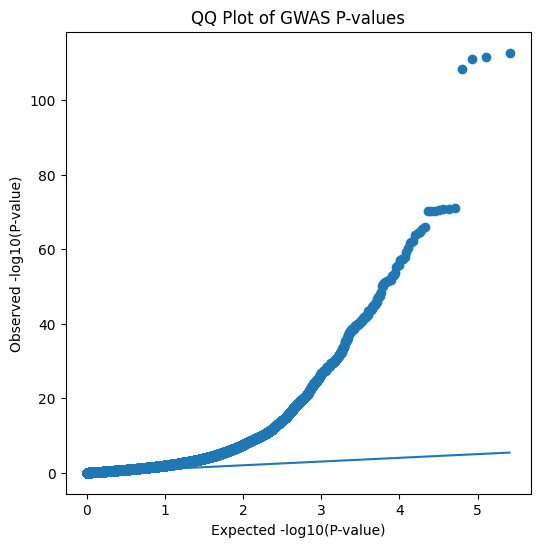

In [ ]:
# A QQ plot compares the observed p-values against what we would expect by chance.
# Expected p-values are uniformly distributed between 0 and 1.

# 1. Sort the observed p-values from smallest to largest
# TODO
observed_pvals = gwas_df['p'].sort_values().values

# 2. Generate expected p-values
# The expected p-values are roughly (rank) / (total_number_of_SNPs + 1)
# TODO: Create an array of expected p-values
expected_pvals = np.arange(1, len(observed_pvals) + 1) / (len(observed_pvals) + 1)

# 3. Plot the QQ plot
plt.figure(figsize=(6, 6))

# TODO: Scatter plot of expected (x-axis) vs observed (y-axis)
plt.scatter(-np.log10(expected_pvals), -np.log10(observed_pvals))

# TODO: Draw the diagonal line (y = x) representing the null hypothesis
# Hint: plot from [0, max(exp_log_p)] to [0, max(exp_log_p)]
null_hypothesis = -np.log10(expected_pvals)
plt.plot([0, max(null_hypothesis)], [0, max(null_hypothesis)])

plt.title("QQ Plot of GWAS P-values")
plt.xlabel("Expected -log10(P-value)")
plt.ylabel("Observed -log10(P-value)")
plt.show()

## 1.5 Calculating the Genomic Inflation Factor (5 Pts)

When conducting a GWAS, it is entirely possible that systematic biases—most commonly population stratification (e.g., mixing different ancestral populations)—can cause -values to look artificially significant across the entire genome. We can quantify this global bias using the Genomic Inflation Factor (Lambda). It is defined as the ratio of the median observed  (chi-squared) test statistic to the expected median  statistic under the null hypothesis.

The expected median of a  distribution with 1 degree of freedom is approximately `0.4549`.
Calculate and print your Genomic Inflation Factor value. Do you see the GWAS shows signs of inflation? Can you explain why?

In [ ]:
# 1. Find the median observed p-value
# TODO
median_pval = np.median(gwas_df['p'])

# 2. Convert the median p-value to an observed chi-squared statistic
# TODO
chi2_observed = stats.chi2.ppf(1 - median_pval, df=1)

# 3. Calculate lambda
# TODO
lambda_gc = chi2_observed / 0.4549

print(f"Genomic Inflation Factor (lambda): {lambda_gc:.3f}")

Genomic Inflation Factor (lambda): 1.920


#### Explain your result here:
The genomic inflation factor is 1.92, which is above 1 and indicates inflation in the test statistics. For a highly polygenic trait like height (https://www.biologyonline.com/dictionary/polygenic-trait), part of this inflation may reflect many true small genetic effects across the genome. However, lambda alone cannot distinguish true polygenic signal from confounding factors such as population stratification, so the result suggests inflation but does not prove the cause by itself.

## Part 2: Variational Autoencoder on DermaMNIST

### Introduction

A **Variational Autoencoder (VAE)** is a generative model that, like a standard autoencoder, consists of an **encoder** and a **decoder** network. The encoder $q_{\phi}(z|x)$ takes an input (such as an image) and maps it into a **latent space** – instead of producing a single latent vector, it produces a **probability distribution** (typically a Gaussian with parameters $\mu$ and $\sigma$) that represents the encoding of the input. The decoder $p_{\theta}(x|z)$ then takes a sample $z$ from this latent distribution and tries to **reconstruct** the original input. The latent space is a compressed, abstract representation of the data where similar inputs are expected to lie close together. In a VAE, this latent space is **continuous and probabilistic**, which allows us not only to reconstruct inputs but also to generate **new** data by sampling from the latent space.  

**Key components of a VAE:**

- **Encoder ($x \to z$):** The encoder network transforms an input $x$ into the parameters of a distribution over the latent variable $z$. Commonly, it outputs a vector of means $\mu$ and a vector of (log) variances $\log\sigma^2$ for a Gaussian distribution $q_{\phi}(z|x) = \mathcal{N}(z;\mu(x), \mathrm{diag}(\sigma^2(x)))$. This distribution reflects uncertainty about how $x$ is represented in latent space.

- **Latent space & reparameterization:** Instead of directly sampling $z \sim \mathcal{N}(\mu, \sigma^2)$ inside the network (which would break backpropagation due to the random sampling), VAEs use the **reparameterization trick**. We sample an auxiliary noise $\epsilon \sim \mathcal{N}(0, I)$ and then **reparameterize** as
  $$z = \mu + \sigma \odot \epsilon,$$
  where $\sigma = \exp(0.5 \cdot \log\sigma^2)$ and $\odot$ is elementwise multiplication. This way, $\mu$ and $\sigma$ are treated as deterministic outputs of the encoder, and the randomness is pushed to $\epsilon$, which is independent of the network parameters. This trick allows gradients to flow through $z$ via $\mu$ and $\sigma$ during training.

- **Decoder ($z \to \hat{x}$):** The decoder network takes a latent sample $z$ and produces a reconstruction $\hat{x}$ in the original data space. The decoder is trained to make $\hat{x}$ as close as possible to the original $x$. In a generative sense, if we sample $z$ from the latent prior (often a standard Normal $\mathcal{N}(0,I)$), the decoder can generate *new* samples that resemble the training data.

- **Loss function (ELBO):** VAEs are trained by maximizing the Evidence Lower Bound (ELBO) on the data log-likelihood. In practice, this corresponds to minimizing a loss that has two terms: a **reconstruction loss** and a **KL divergence** loss. The reconstruction loss ensures the decoded output $\hat{x}$ is similar to the input $x$ (for example, using binary cross-entropy or mean squared error between $x$ and $\hat{x}$). The **KL divergence** term $D_{\mathrm{KL}}(q_{\phi}(z|x)\,\|\,p(z))$ acts as a regularizer, pushing the encoder’s output distribution $q_{\phi}(z|x)$ to be close to the chosen prior $p(z)$ (usually $p(z) = \mathcal{N}(0,I)$). The KL term effectively encourages the latent space to be well-organized and prevents the encoder from just memorizing the inputs. Mathematically, for one data point $x$, the loss (to minimize) can be written as:  
  $$\mathcal{L}(x) = \underbrace{\mathbb{E}_{q_{\phi}(z|x)}[-\log p_{\theta}(x|z)]}_{\text{Reconstruction Loss}} \;+\; \underbrace{D_{\mathrm{KL}}\!\big(q_{\phi}(z|x)\,\|\,p(z)\big)}_{\text{KL Divergence}}.$$  
  In simpler terms, we want $\hat{x}$ to be accurate (low reconstruction error) while keeping the latent $z$ distributions close to $N(0,I)$ (via a low KL divergence). Balancing these two forces prevents overfitting and yields a model that can generate realistic new data.

**Conditional VAE (CVAE):**

In a *conditional* VAE, we incorporate additional information (like a class label $y$) into the encoder and decoder. This means the encoder learns $q(z|x,y)$ and the decoder learns $p(x|z,y)$. In practice, we feed the class label into both networks (for example, by concatenating a one-hot encoded label to the input or latent vector). By doing so, the VAE learns a latent space that is structured *per class*, and we can generate new examples conditioned on a specific class. In this assignment, we will implement a **conditional VAE on the DermaMNIST dataset**, conditioning on the disease label for each dermatoscopic image. DermaMNIST is a part of the MedMNIST collection of medical image datasets and contains 28×28 skin lesion images categorized into 7 classes of skin diseases (derived from the HAM10000 dataset).

### Assignment Overview

In this assignment, you will build and train a conditional VAE on the **DermaMNIST** dataset using PyTorch. We will proceed through the following steps:
1. **Data Loading and Preprocessing:** Use the MedMNIST API to load DermaMNIST and prepare data loaders with appropriate transformations.
2. **Implementing the VAE Architecture:** Define the encoder and decoder networks for a conditional VAE. The architecture will incorporate image data and condition on class labels.
3. **Training Loop:** Train the VAE using the reconstruction + KL divergence loss. Implement the forward pass, reparameterization, loss computation, and backpropagation.
4. **Latent Space Visualization:** Use UMAP to project the learned latent space to 2D and visualize how the data clusters by class in the latent space.
5. (**Bonus:** *optional*) **Generation of New Samples:** Sample random latent vectors and pass them through the decoder to generate new skin lesion images for a given condition (class label).

Throughout the notebook, **fill in the code where indicated** (look for comments like `TODO` or blank placeholders). Short descriptions are provided to guide you for each part.

## 2.1: Data Loading and Preprocessing (5 pts)

In this section, we will load the DermaMNIST dataset and prepare it for training our VAE. DermaMNIST contains 28×28 color images of skin lesions across 7 classes. We will use the `medmnist` package to download and load the dataset easily. The tasks are:
1. **Define a transformation pipeline** for the images. At minimum, convert images to PyTorch tensors (and optionally normalize the pixel values).
2. **Load the DermaMNIST dataset** for training, validation, and testing splits using the provided MedMNIST classes.
3. **Create DataLoader objects** for each split to enable batching during training and evaluation.

*Hint:* Use `medmnist.DermaMNIST` class with the `split` argument as `'train'`, `'val'`, or `'test'`. The dataset returns images (as PIL images or arrays) and their labels. You can specify `transform=...` to apply the transformations defined. You might need to `pip install medmnist` if it's not already available.

Source 1: https://docs.pytorch.org/vision/0.8/transforms.html#:~:text=Transforms%20are%20common%20image%20transformations,the%20images%20of%20the%20batch.

Source 2: https://docs.pytorch.org/tutorials/beginner/basics/data_tutorial.html

But first, install medmnist

In [ ]:
!pip install medmnist

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 6.6 MB/s eta 0:00:00


In [ ]:
import torch
from torch.utils.data import DataLoader
from torchvision import transforms

# 1. Define image transformations: convert images to tensor and (optionally) normalize.
# TODO
transform = transforms.ToTensor()   # Source: https://docs.pytorch.org/vision/0.8/transforms.html#:~:text=Transforms%20are%20common%20image%20transformations,the%20images%20of%20the%20batch.

# 2. Load the DermaMNIST dataset for train, val, and test splits.
# If medmnist is not installed, install it via pip: !pip install medmnist
from medmnist import DermaMNIST

batch_size = 128  # feel free to adjust batch size
download = True  # download dataset if not already downloaded

train_dataset = DermaMNIST(split='train', transform=transform, download=download)
val_dataset   = DermaMNIST(split='val',   transform=transform, download=download)
test_dataset  = DermaMNIST(split='test',  transform=transform, download=download)

# 3. Create DataLoader for each split.
# TODO
# Source: https://docs.pytorch.org/tutorials/beginner/basics/data_tutorial.html
train_loader = DataLoader(train_dataset, batch_size = batch_size, shuffle = True)
val_loader = DataLoader(val_dataset, batch_size = batch_size, shuffle = False)
test_loader = DataLoader(test_dataset, batch_size = batch_size, shuffle = False)

# 4. Set device (use GPU if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

100%|██████████| 19.7M/19.7M [00:01<00:00, 13.5MB/s]


In [ ]:
# Quick sanity check: get one batch
images, labels = next(iter(train_loader))
print(f"Batch of images shape: {images.shape}")   # expected: (batch_size, 3, 28, 28)
print(f"Batch of labels shape: {labels.shape}")   # expected: (batch_size,)  labels are class indices 0-6
print(f"Unique labels in this batch: {labels.unique().tolist()}")

Batch of images shape: torch.Size([128, 3, 28, 28])
Batch of labels shape: torch.Size([128, 1])
Unique labels in this batch: [0, 1, 2, 3, 4, 5, 6]


## 2.2: Implementing the Encoder and Decoder (15 pts)
Now, let's build the neural network architecture for our conditional VAE. We will create two modules: an **Encoder** that takes an image (and condition label) as input and produces the latent distribution parameters, and a **Decoder** that takes a latent vector (and condition label) and reconstructs the image. Because this is a *conditional* VAE, we need to incorporate the class label $y$ at both stages:
- In the **Encoder**, $y$ can be included by concatenating a one-hot representation of $y$ with the image features before the final layers that produce $\mu$ and $\log\sigma^2$.
- In the **Decoder**, $y$ can be included by concat enating a one-hot $y$ with $z$ before the first decoding layer.

We will use a simple convolutional neural network (CNN) architecture for both encoder and decoder (since the images are 28×28, we can also use fully-connected layers, but CNN will better capture spatial structure). Parts of the architecture are given, and you will fill in the missing pieces.

**Encoder Architecture (example):** A possible design is:
- Convolutional layers to encode the 28×28×3 image into a smaller feature map.
- Flatten and concatenate with the label’s one-hot vector.
- Two linear layers to output `mu` and `log_var` (each of dimension `latent_dim`).

**Decoder Architecture (example):** A reverse process:
- Take the sampled latent vector and concatenate with label one-hot.
- A linear layer to expand into a feature map shape.
- Transposed convolution (or upsampling + conv) layers to reconstruct the image from the latent features.
- The final layer should produce 3×28×28 output (the reconstructed image), likely followed by a sigmoid activation (to bound pixel values between 0 and 1).

Complete the code below by filling in the `TODO` sections for the encoder and decoder implementation. To improve training stability and prevent overfitting, you must include at least one regularization technique (e.g., BatchNorm or Dropout) in both your encoder and decoder pathways.

Source 1: https://www.geeksforgeeks.org/machine-learning/implement-convolutional-autoencoder-in-pytorch-with-cuda/

Source 2: https://docs.pytorch.org/docs/stable/generated/torch.nn.Linear.html

Source 3: https://docs.pytorch.org/docs/stable/generated/torch.cat.html

Source 4: https://docs.pytorch.org/docs/stable/generated/torch.nn.ConvTranspose2d.html

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

latent_dim = 128        # Dimensionality of the latent space (you can adjust, e.g., 16 or 32)
num_classes = 7        # DermaMNIST has 7 classes
img_channels = 3       # RGB images

class Encoder(nn.Module):
    def __init__(self, latent_dim, num_classes):
        super(Encoder, self).__init__()
        # TODO
        # Convolutional encoder
        # Source 1: https://www.geeksforgeeks.org/machine-learning/implement-convolutional-autoencoder-in-pytorch-with-cuda/
        self.conv = nn.Sequential(
            nn.Conv2d(img_channels, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU()
        )

        # Linear layers for mean and log-variance, taking into account label conditioning
        # Source 2: https://docs.pytorch.org/docs/stable/generated/torch.nn.Linear.html
        self.fc_mu = nn.Linear(64 * 7 * 7 + num_classes, latent_dim) # fully connected layer
        self.fc_logvar = nn.Linear(64 * 7 * 7 + num_classes, latent_dim)

    def forward(self, x, y):
        # TODO
        # pass image through conv layers
        x = self.conv(x)
        x = x.view(x.size(0), -1)  # flatten (reshape tensor without changing data)

        # one-hot encode label and concatenate
        # Source 3: https://docs.pytorch.org/docs/stable/generated/torch.cat.html
        y_onehot = F.one_hot(y.squeeze(1), num_classes=num_classes).float() #one hot function
        x = torch.cat([x, y_onehot], dim=1) #concatenate function
        mu = self.fc_mu(x)
        log_var = self.fc_logvar(x)
        return mu, log_var

class Decoder(nn.Module):
    def __init__(self, latent_dim, num_classes):
        super(Decoder, self).__init__()
        # TODO
        # Linear layer to expand z (with label) into a feature map
        self.fc = nn.Linear(latent_dim + num_classes, 64 * 7 * 7)
        self.bn1 = nn.BatchNorm2d(64) # batch normalization 1
        self.bn2 = nn.BatchNorm2d(32) # batch normalization 2

        # Transposed conv layers to upscale to 28x28
        # Source 4: https://docs.pytorch.org/docs/stable/generated/torch.nn.ConvTranspose2d.html
        self.deconv1 = nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1) #from source 4
        self.deconv2 = nn.ConvTranspose2d(32, 3,  kernel_size=4, stride=2, padding=1)

    def forward(self, z, y):
        # TODO
        # Source 3: https://docs.pytorch.org/docs/stable/generated/torch.cat.html
        y_onehot = F.one_hot(y.squeeze(1), num_classes=num_classes).float()
        z = torch.cat([z, y_onehot], dim=1)
        x = self.fc(z)
        x = x.view(x.size(0), 64, 7, 7)
        x = F.relu(self.bn1(x))
        x = F.relu(self.bn2(self.deconv1(x)))
        recon_x = torch.sigmoid(self.deconv2(x))
        return recon_x

In [ ]:
# Instantiate encoder and decoder
encoder = Encoder(latent_dim, num_classes).to(device)
decoder = Decoder(latent_dim, num_classes).to(device)

# Test the encoder and decoder with a dummy input
x_sample, y_sample = images[0:2].to(device), labels[0:2].to(device) # take a couple of examples from the earlier batch
mu, log_var = encoder(x_sample, y_sample)
print("Encoder output shapes:", mu.shape, log_var.shape)  # each [2, latent_dim]
z_sample = torch.randn_like(mu)  # a random latent vector (for testing decoder)
x_recon = decoder(z_sample, y_sample)
print("Decoder output shape:", x_recon.shape)  # expected [2, 3, 28, 28]

Encoder output shapes: torch.Size([2, 128]) torch.Size([2, 128])
Decoder output shape: torch.Size([2, 3, 28, 28])


## 2.3: Training the VAE (15 pts)

Now that we have our encoder and decoder, the next step is to train the VAE. In training, we will:
- Iterate over batches of training data.
- For each batch, **encode** the images to get $\mu$ and $\log\sigma^2$.
- **Sample** a latent vector $z$ using the reparameterization trick.
- **Decode** $z$ to get reconstructed images.
- Compute the **loss**: sum of reconstruction loss and KL divergence loss.
- Backpropagate and update the model parameters.

The KL divergence term for a single data point is given by:  
$$D_{\mathrm{KL}}(q(z|x) \parallel p(z)) = -\frac{1}{2} \sum_{j=1}^{d} \Big(1 + \log\sigma_j^2 - \mu_j^2 - \sigma_j^2 \Big),$$  
where $d$ is the latent dimension. We will implement this formula.

Fill in the code below to complete the training loop. Look for places marked `TODO`:
- Implement the reparameterization to obtain `z` from `mu` and `log_var`.
- Compute the `recon_loss`.
- Compute the `kl_loss` using the formula above.
- Sum the losses to get `total_loss` and perform backpropagation.

Source 1: https://docs.pytorch.org/docs/stable/optim.html

Source 2: the assignment instructions for defining all the formulas

In [ ]:
import torch.optim as optim
# TODO
# Optimizer
# Source: https://docs.pytorch.org/docs/stable/optim.html
optimizer = optim.Adam(list(encoder.parameters()) + list(decoder.parameters()), lr=0.001) #combine parameters so that optimizer updates both at the same time

# Training parameters (feel free to adjust)
num_epochs = 200
beta = 0.001

for epoch in range(num_epochs):
    encoder.train()
    decoder.train()
    train_loss = 0.0
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        # Encode
        mu, log_var = encoder(images, labels)
        # Reparameterization: sample z from N(mu, sigma^2)
        # TODO: implement reparameterization trick
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        z = mu + eps * std

        # TODO
        # Compute reconstruction loss
        recon_x = decoder(z, labels)
        recon_loss = F.binary_cross_entropy(recon_x, images, reduction='sum')

        # Compute KL divergence loss
        kl_loss = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())

        # Total VAE loss
        loss = recon_loss + beta * kl_loss

        # Backpropagation and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
    # Report average loss for the epoch (feel free to adjust)
    avg_loss = train_loss / len(train_loader)
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], Average Loss: {avg_loss:.4f}")

Epoch [10/200], Average Loss: 176606.1119
Epoch [20/200], Average Loss: 176354.2798
Epoch [30/200], Average Loss: 176242.7528
Epoch [40/200], Average Loss: 176216.5295
Epoch [50/200], Average Loss: 176168.9304
Epoch [60/200], Average Loss: 176142.2428
Epoch [70/200], Average Loss: 176115.2604
Epoch [80/200], Average Loss: 176083.5506
Epoch [90/200], Average Loss: 176081.3064
Epoch [100/200], Average Loss: 176066.2955
Epoch [110/200], Average Loss: 176056.2009
Epoch [120/200], Average Loss: 176048.7205
Epoch [130/200], Average Loss: 176048.8409
Epoch [140/200], Average Loss: 176048.1065
Epoch [150/200], Average Loss: 176029.6321
Epoch [160/200], Average Loss: 176005.1284
Epoch [170/200], Average Loss: 176031.5034
Epoch [180/200], Average Loss: 176039.3489
Epoch [190/200], Average Loss: 176005.5822
Epoch [200/200], Average Loss: 176004.1426


After training for several epochs, you should observe the loss decreasing. During training, you might also consider monitoring the separate components of the loss (e.g., print `recon_loss.item()` and `kl_loss.item()` averages) to see the balance between reconstruction and KL. Over time, the encoder will learn to encode meaningful latent distributions and the KL term will balance with reconstruction quality.

Question: Propose a strategy to dynamically adjust the $\beta$ parameter during the training process. Describe how your adjustment strategy works mathematically or programmatically across the num_epochs. Compared to using a static $\beta$, how do you expect the specific impact on the balance between recon_loss and kl_loss after implementing this strategy?

Source 1: https://medium.com/@chengjing/a-must-have-training-trick-for-vae-variational-autoencoder-d28ff53b0023

Source 2: https://github.com/larngroup/KL_divergence_loss

A simple strategy is to apply annealing schedules for the KL term (known as monotonic annealing or KL annealing (source 1)). The goal is to make the beta increase (from 0 to 1) over training. It mitigates "KL vanishing" or "posterior collapse", where the decoder ignores latent variables. Programmably this can be done using **beta = epoch / num_epochs**.
At the start, beta is near 0 so the model focuses entirely on minimizing recon_loss and learns to reconstruct images without the KL term. As training progresses, beta grows and kl_loss gradually pushes the latent space towards a standard normal distribution. Compared to a static beta, this gets rid of the "KL vanishing" problem that we just discussed.
The result of this would be better reconstructions early on while still achieving a well-organised latent space at the end.





## 2.4 Evaluation: Visualize Reconstructions (15 pts)

Now that you have completed the training of your conditional VAE, it is time to evaluate its performance by visualizing how well it reconstructs images from the test set. In this section, you will:

- Set your encoder and decoder to evaluation mode.
- Retrieve a batch of test images along with their corresponding labels.
- Use the encoder to compute the latent representations (`mu` and `logvar`), apply the reparameterization trick to obtain latent vectors, and then use the decoder to reconstruct the images.
- Plot a grid showing the original images in the first row and their corresponding reconstructions in the second row. Each original image should display its true label.

Implement this evaluation code in your notebook. Carefully compare the original images with the reconstructions to assess whether your VAE has captured the essential features of the data. If the reconstructions are poor, consider revisiting your model architecture or training procedure.

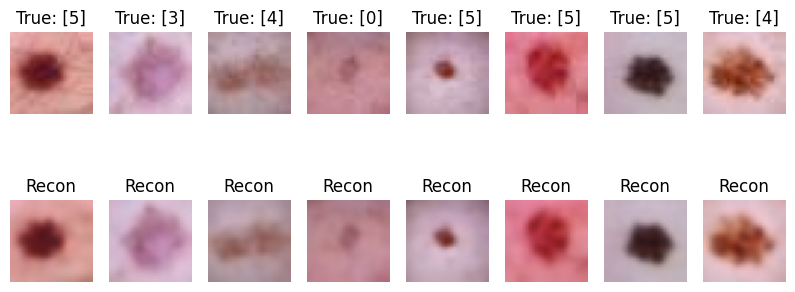

In [ ]:
# -------------------------------
# Evaluation: Visualize Reconstructions
# -------------------------------
import numpy as np
import matplotlib.pyplot as plt

encoder.eval()
decoder.eval()
test_iter = iter(test_loader)
images, labels = next(test_iter)
images = images.to(device)
labels = labels.to(device).long()

with torch.no_grad():
    # TODO: generate recon (reconstructed images)
    mu, log_var = encoder(images, labels)
    std = torch.exp(0.5 * log_var)
    eps = torch.randn_like(std)
    z = mu + eps * std
    recon = decoder(z, labels)

plt.figure(figsize=(10, 4))
examples = 8

for i in range(examples):
    # Original image
    plt.subplot(2, examples, i + 1)
    plt.imshow(images[i].cpu().numpy().transpose(1, 2, 0)) #there was an error here, need to convert to numpy first
    plt.title(f"True: [{labels[i].item()}]")
    plt.axis('off')
    # Reconstructed image
    plt.subplot(2, examples, examples + i + 1)
    plt.imshow(recon[i].cpu().numpy().transpose(1, 2, 0))
    plt.title("Recon")
    plt.axis('off')
plt.show()

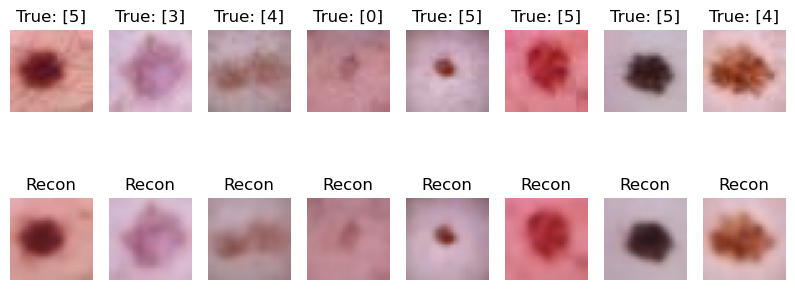

In [ ]:
## Expected Output:

## 2.5: Visualize Latent Space (15 pts)

Once the model is trained, we want to inspect the **latent space** to see if it has learned a meaningful organization of the data. One way to do this is to take a bunch of images, encode them to get their latent vectors (specifically, we can use the mean $\mu$ as the representation for each image), and then visualize these vectors in 2D. Since our latent space might be higher-dimensional (e.g. 16D), we will use **UMAP** (Uniform Manifold Approximation and Projection) to reduce the dimensionality to 2 for visualization. UMAP often preserves local and global structure of the data better than t-SNE or PCA for many cases.
**Steps:**
1. Use the trained encoder to compute $\mu$ for each image in the test set (concatenate all these latent vectors).
2. Use UMAP to transform the collection of latent vectors into 2D.
3. Create a scatter plot where each point is the 2D UMAP embedding of an image's latent vector, colored by its class label.

*Note:* You may need to install the UMAP library: `pip install umap-learn`. Also, ensure you have matplotlib for plotting.

Source 1: https://umap-learn.readthedocs.io/en/latest/basic_usage.html

Source 2: https://matplotlib.org/stable/api/colorbar_api.html

Source 3: https://matplotlib.org/stable/users/explain/colors/colormaps.html

In [ ]:
!pip install umap-learn

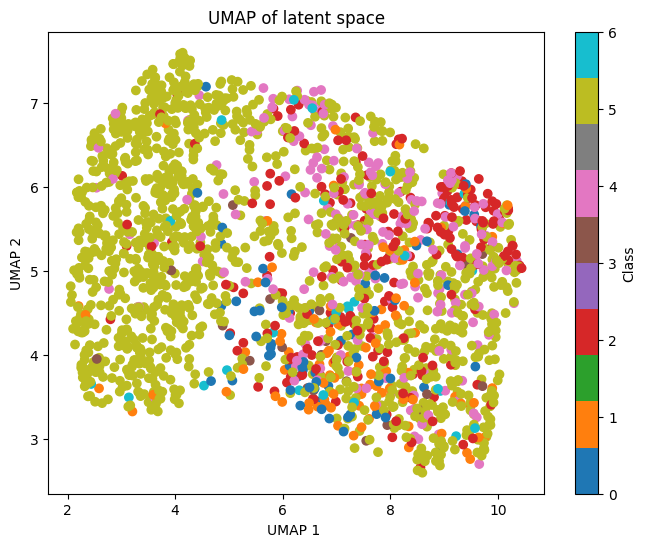

In [ ]:
# If UMAP is not installed, install it: !pip install umap-learn
import umap

encoder.eval()  # set encoder to evaluation mode
all_latents = []
all_labels = []

# Encode all test images to get their latent means
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        mu, log_var = encoder(images, labels)
        all_latents.append(mu.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

# Stack all batches together
all_latents = np.concatenate(all_latents, axis=0)  # shape [N_test_samples, latent_dim]
all_labels = np.concatenate(all_labels, axis=0)    # shape [N_test_samples]

# TODO
# Use UMAP to reduce latent dimensions to 2 for visualization
# Source 1: https://umap-learn.readthedocs.io/en/latest/basic_usage.html
reducer = umap.UMAP(n_components= 2);
latents_2d = reducer.fit_transform(all_latents)

# Plot the 2D latent space
# TODO: create a scatter plot of latents_2d, colored by all_labels
# Source 2: https://matplotlib.org/stable/api/colorbar_api.html
# Source 3: https://matplotlib.org/stable/users/explain/colors/colormaps.html
plt.figure(figsize=(8,6))
scatter = plt.scatter(latents_2d[:,0], latents_2d[:,1], c=all_labels, cmap='tab10')
plt.colorbar(scatter, label='Class')
plt.title("UMAP of latent space")
plt.xlabel("UMAP 1 ")
plt.ylabel("UMAP 2")
plt.show()

## Bonus (Optional): Generating New Samples Conditioned on a Class (10 pts)

As a bonus exercise, you can use the trained VAE to **generate new images** of skin lesions by sampling from the latent space. Because our VAE is conditional, we can direct the generation by choosing a class label.

**What to do:**  
Pick a label (0 through 6, corresponding to one of the skin lesion categories in DermaMNIST), sample random latent vectors from the standard Normal prior $p(z) = \mathcal{N}(0,I)$, and feed them into the decoder along with the chosen label. This will produce novel images that (hopefully) resemble lesions of that class.

This part is open-ended – feel free to experiment by generating multiple samples and visualizing them.

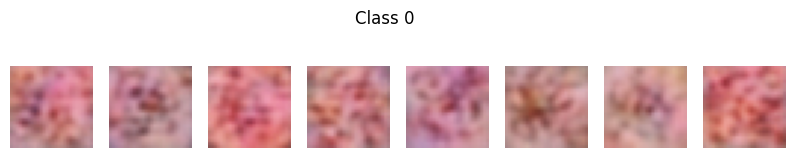

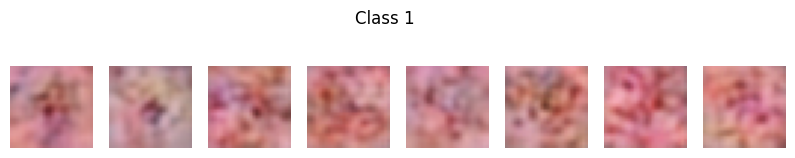

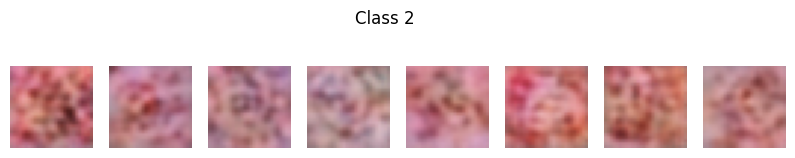

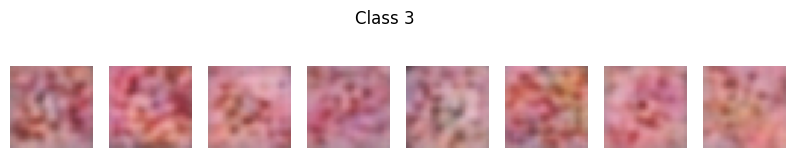

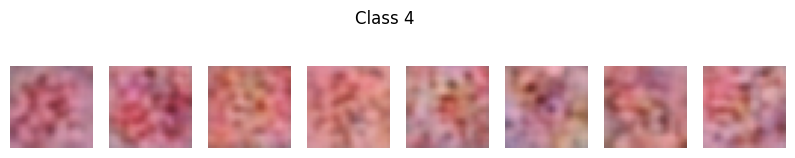

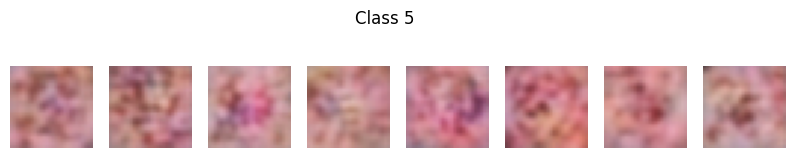

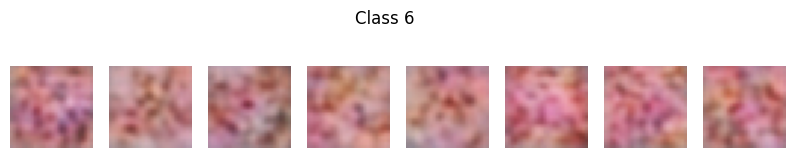

In [ ]:
decoder.eval()
with torch.no_grad(): # Source: https://docs.pytorch.org/docs/stable/generated/torch.no_grad.html
    for chosen_class in range(7):
        z = torch.randn(8, latent_dim).to(device)
        labels_gen = torch.full((8, 1), chosen_class).long().to(device)
        generated = decoder(z, labels_gen)
        plt.figure(figsize=(10, 2))
        for i in range(8):
            plt.subplot(1, 8, i + 1)
            plt.imshow(generated[i].cpu().numpy().transpose(1, 2, 0))
            plt.axis('off')
        plt.suptitle(f"Class {chosen_class}")
        plt.show()